In [9]:
import pandas as pd
import numpy as np
#for data manipulations


import matplotlib.pyplot as plt
import seaborn as sns
# for plotting the data

pd.set_option('display.max_columns',None)
#set options allows to chnage seeting in showing the dataste this hsows all the columns in df 

from xgboost import XGBClassifier 
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
#for data modelling 

from sklearn.model_selection import GridSearchCV , train_test_split 
from sklearn.metrics import accuracy_score , precision_score , recall_score, f1_score , confusion_matrix , ConfusionMatrixDisplay , classification_report 
from sklearn.metrics import roc_auc_score , roc_curve
from sklearn.tree import plot_tree
#for metics and helpful functions

#for saving models 
import pickle



In [11]:
df=pd.read_csv("churn_data.csv")
df.head(100)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8637-XJIVR,Female,0,No,No,12,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,78.95,927.35,Yes
96,9803-FTJCG,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Credit card (automatic),66.85,4748.7,No
97,0278-YXOOG,Male,0,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,21.05,113.85,Yes
98,3212-KXOCR,Male,0,No,No,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),21.00,1107.2,No


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [14]:
df.isna().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
df.duplicated()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


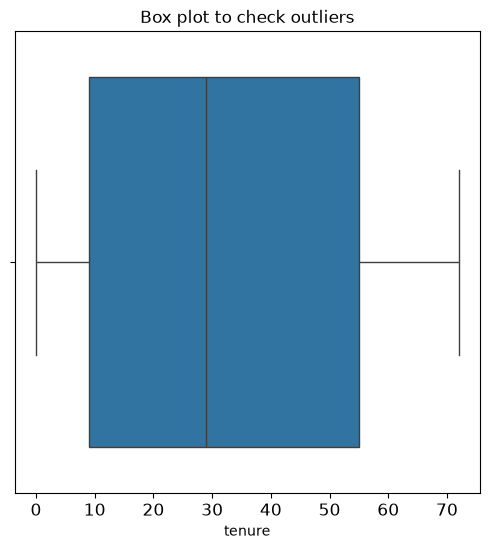

In [23]:
#checking outliers 
plt.figure(figsize=(6,6))
plt.title("Box plot to check outliers",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df['tenure'])
plt.show()

In [26]:
#compute the 25th percentile 
percentile25=df['tenure'].quantile(0.25)
#compute 75th percentile
percentile75=df['tenure'].quantile(0.75)

#computing the interquartile range in tenure 
iqr=percentile75-percentile25

#defining upper limit and lower limits for non -outlier values 
upper_limit= percentile75 + 1.5*iqr
lower_limit=percentile25 - 1.5*iqr

print("upper limit =", upper_limit)
print("lower limit =", lower_limit)

outliers=df[(df['tenure']>upper_limit)|(df['tenure']<lower_limit)]

print("number of rows in the data containg outliers in tenure",len(outliers))

9.0
upper limit = 124.0
lower limit = -60.0
number of rows in the data containg outliers in tenure 0


In [39]:
print(df['Churn_binary'].value_counts())
#number of people churned 
print(df['Churn_binary'].value_counts(normalize=True))
#percentage of people that churned and those who didnt 


Churn_binary
0    5174
1    1869
Name: count, dtype: int64
Churn_binary
0    0.73463
1    0.26537
Name: proportion, dtype: float64


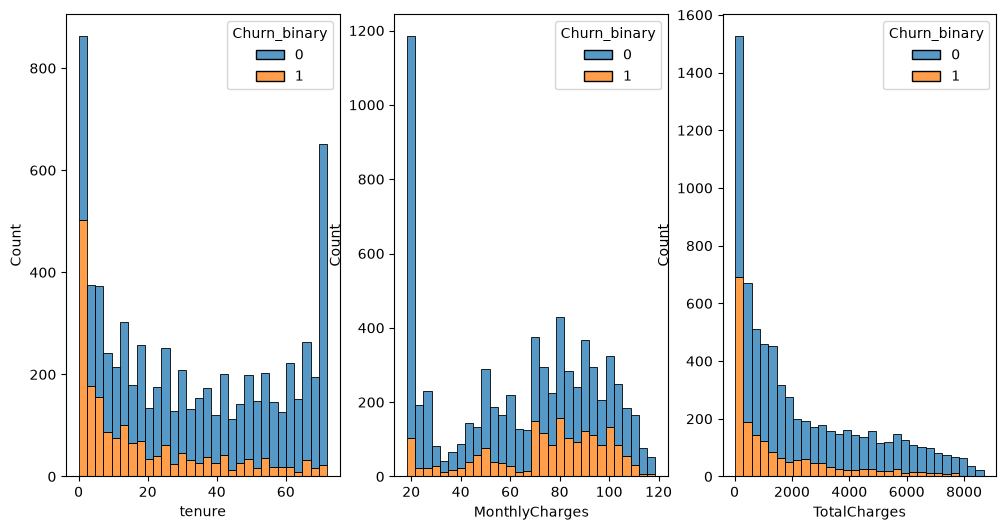

In [49]:
fig,axes=plt.subplots(1,3,figsize=(12,6))
for ax,col in zip(axes,['tenure','MonthlyCharges','TotalCharges']):
    sns.histplot(data=df,x=col,hue='Churn_binary',multiple='stack', bins=30, ax=ax)
#plots for churn by tenure monthly charge and total expense histogram

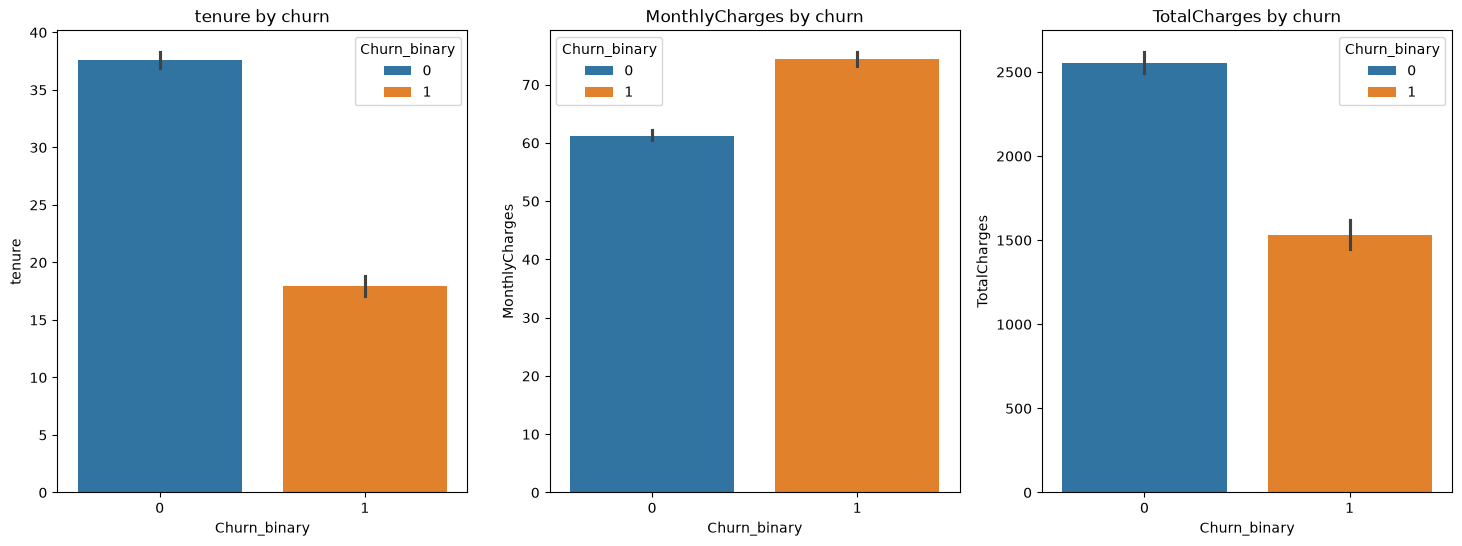

In [54]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
for ax,col in zip(axes,['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.barplot(data=df,x='Churn_binary',y=col,hue='Churn_binary',ax=ax)
    ax.set_title(f'{col} by churn')

(array([0, 1, 2]),
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'One year'),
  Text(2, 0, 'Two year')])

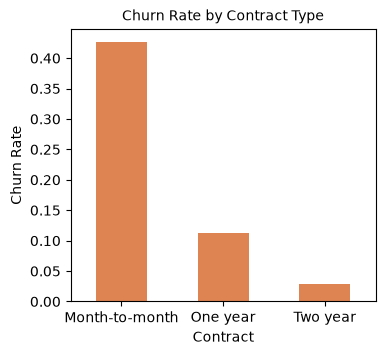

In [64]:
plt.figure(figsize=(10,9,'cm'))
contract_churn = df.groupby('Contract')['Churn_binary'].mean().sort_values(ascending=False)
ax = contract_churn.plot(kind='bar', color='#DD8452')
plt.title('Churn Rate by Contract Type', fontsize=10)
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)



(array([0, 1, 2]),
 [Text(0, 0, 'Fiber optic'), Text(1, 0, 'DSL'), Text(2, 0, 'No')])

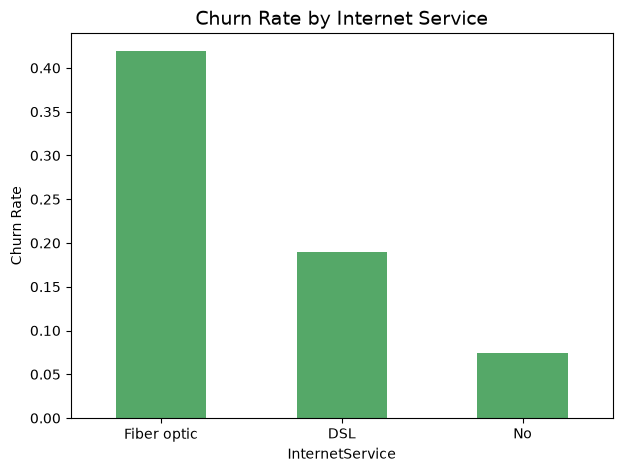

In [66]:
plt.figure(figsize=(7,5))
net_churn = df.groupby('InternetService')['Churn_binary'].mean().sort_values(ascending=False)
ax = net_churn.plot(kind='bar', color='#55A868')
plt.title('Churn Rate by Internet Service', fontsize=14)
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
 

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

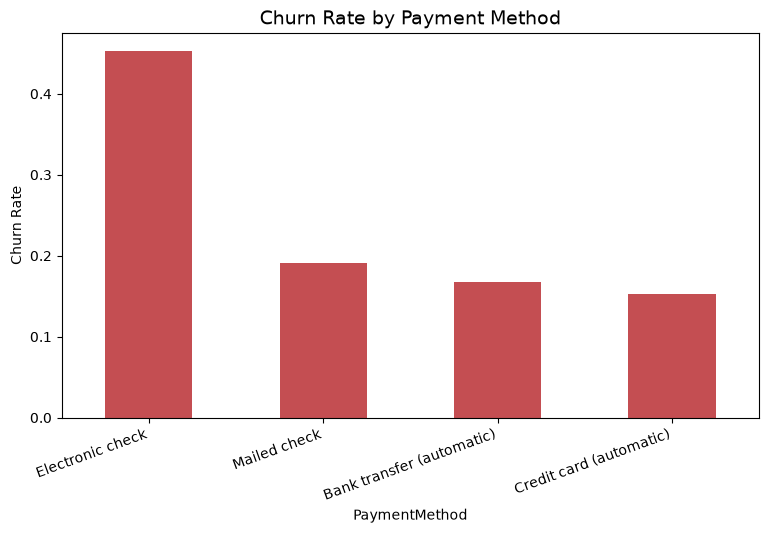

In [70]:
plt.figure(figsize=(9,5))
pay_churn = df.groupby('PaymentMethod')['Churn_binary'].mean().sort_values(ascending=False)
ax = pay_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Payment Method', fontsize=14)
plt.ylabel('Churn Rate')
plt.xticks(rotation=20, ha='right')

Text(0.5, 0, 'Tenure (months)')

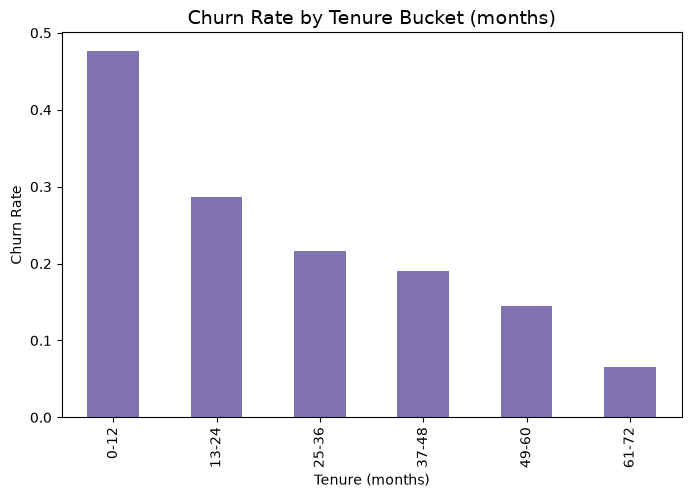

In [73]:

plt.figure(figsize=(8,5))
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72], 
                                     labels=['0-12','13-24','25-36','37-48','49-60','61-72'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn_binary'].mean()
ax = tenure_churn.plot(kind='bar', color='#8172B2')
plt.title('Churn Rate by Tenure Bucket (months)', fontsize=14)
plt.ylabel('Churn Rate')
plt.xlabel('Tenure (months)')
# 7. Churn rate by tenure bucket

Text(0.5, 1.0, 'Correlation Heatmap')

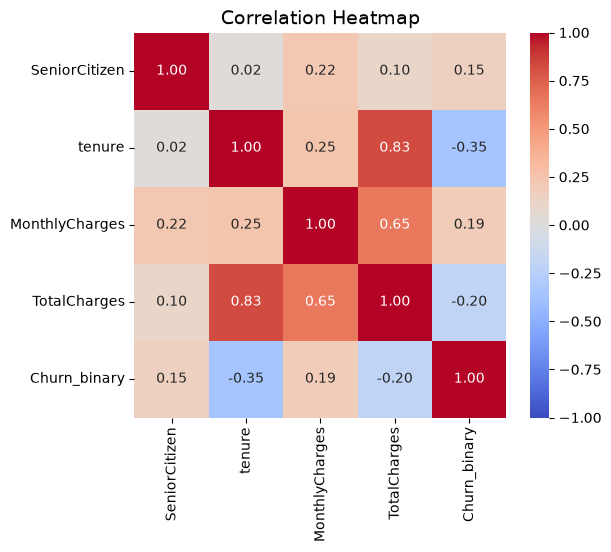

In [75]:
 
# 8. Correlation heatmap (numeric + encoded churn)
plt.figure(figsize=(6,5))
corr_df = df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn_binary']]
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
 

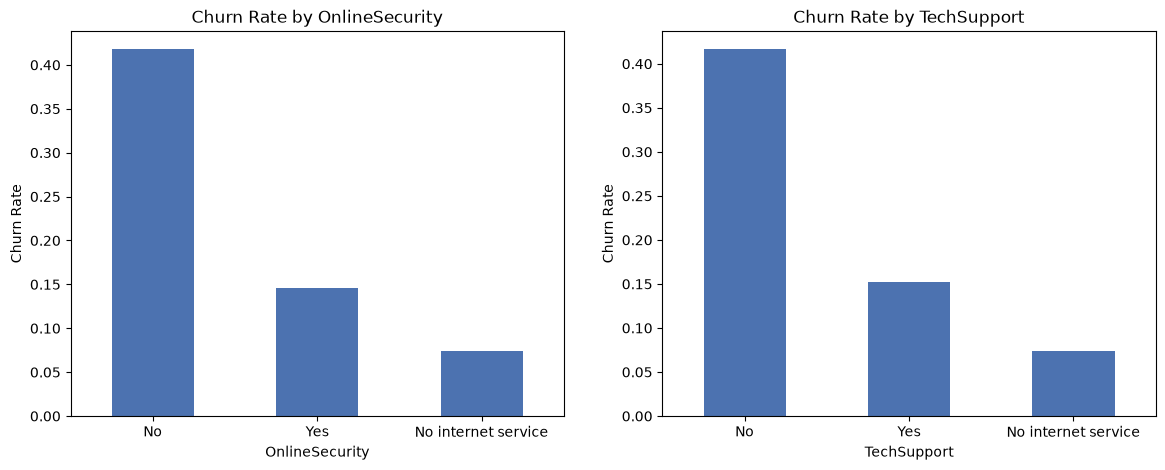

In [77]:
# 9. Churn rate by additional service add-ons (OnlineSecurity, TechSupport)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, col in zip(axes, ['OnlineSecurity', 'TechSupport']):
    rate = df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=0)


Text(0.5, 1.0, 'Monthly Charges vs Tenure by Churn')

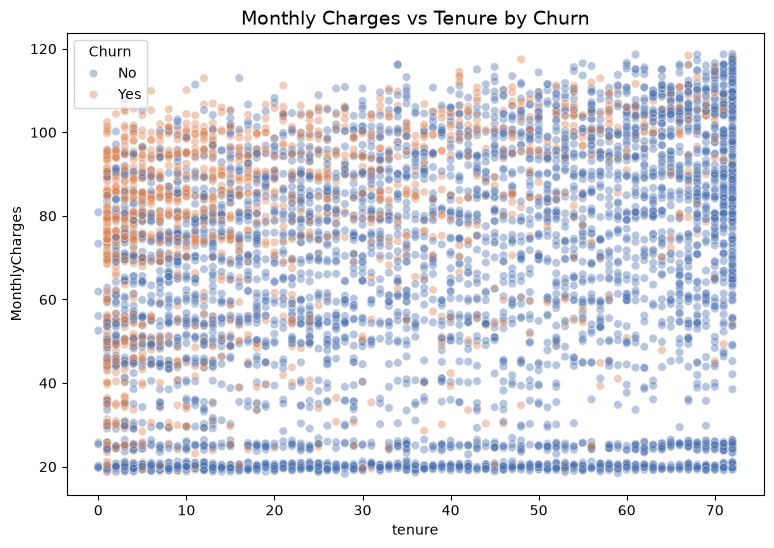

In [79]:
# 10. Scatter: MonthlyCharges vs tenure colored by churn
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=['#4C72B0','#DD8452'])
plt.title('Monthly Charges vs Tenure by Churn', fontsize=14)

In [94]:
#modelling part 
df1=df.copy()

#X contains the training data set
X= df1.drop(columns=['customerID', 'Churn', 'Churn_binary', 'tenure_bucket'])

# Encode binary categoricals
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    X[col] = X[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# One-hot encode multi-category columns
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=multi_cat_cols, drop_first=True,dtype=int)

X['TotalCharges'] = X['TotalCharges'].fillna(0)

X.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


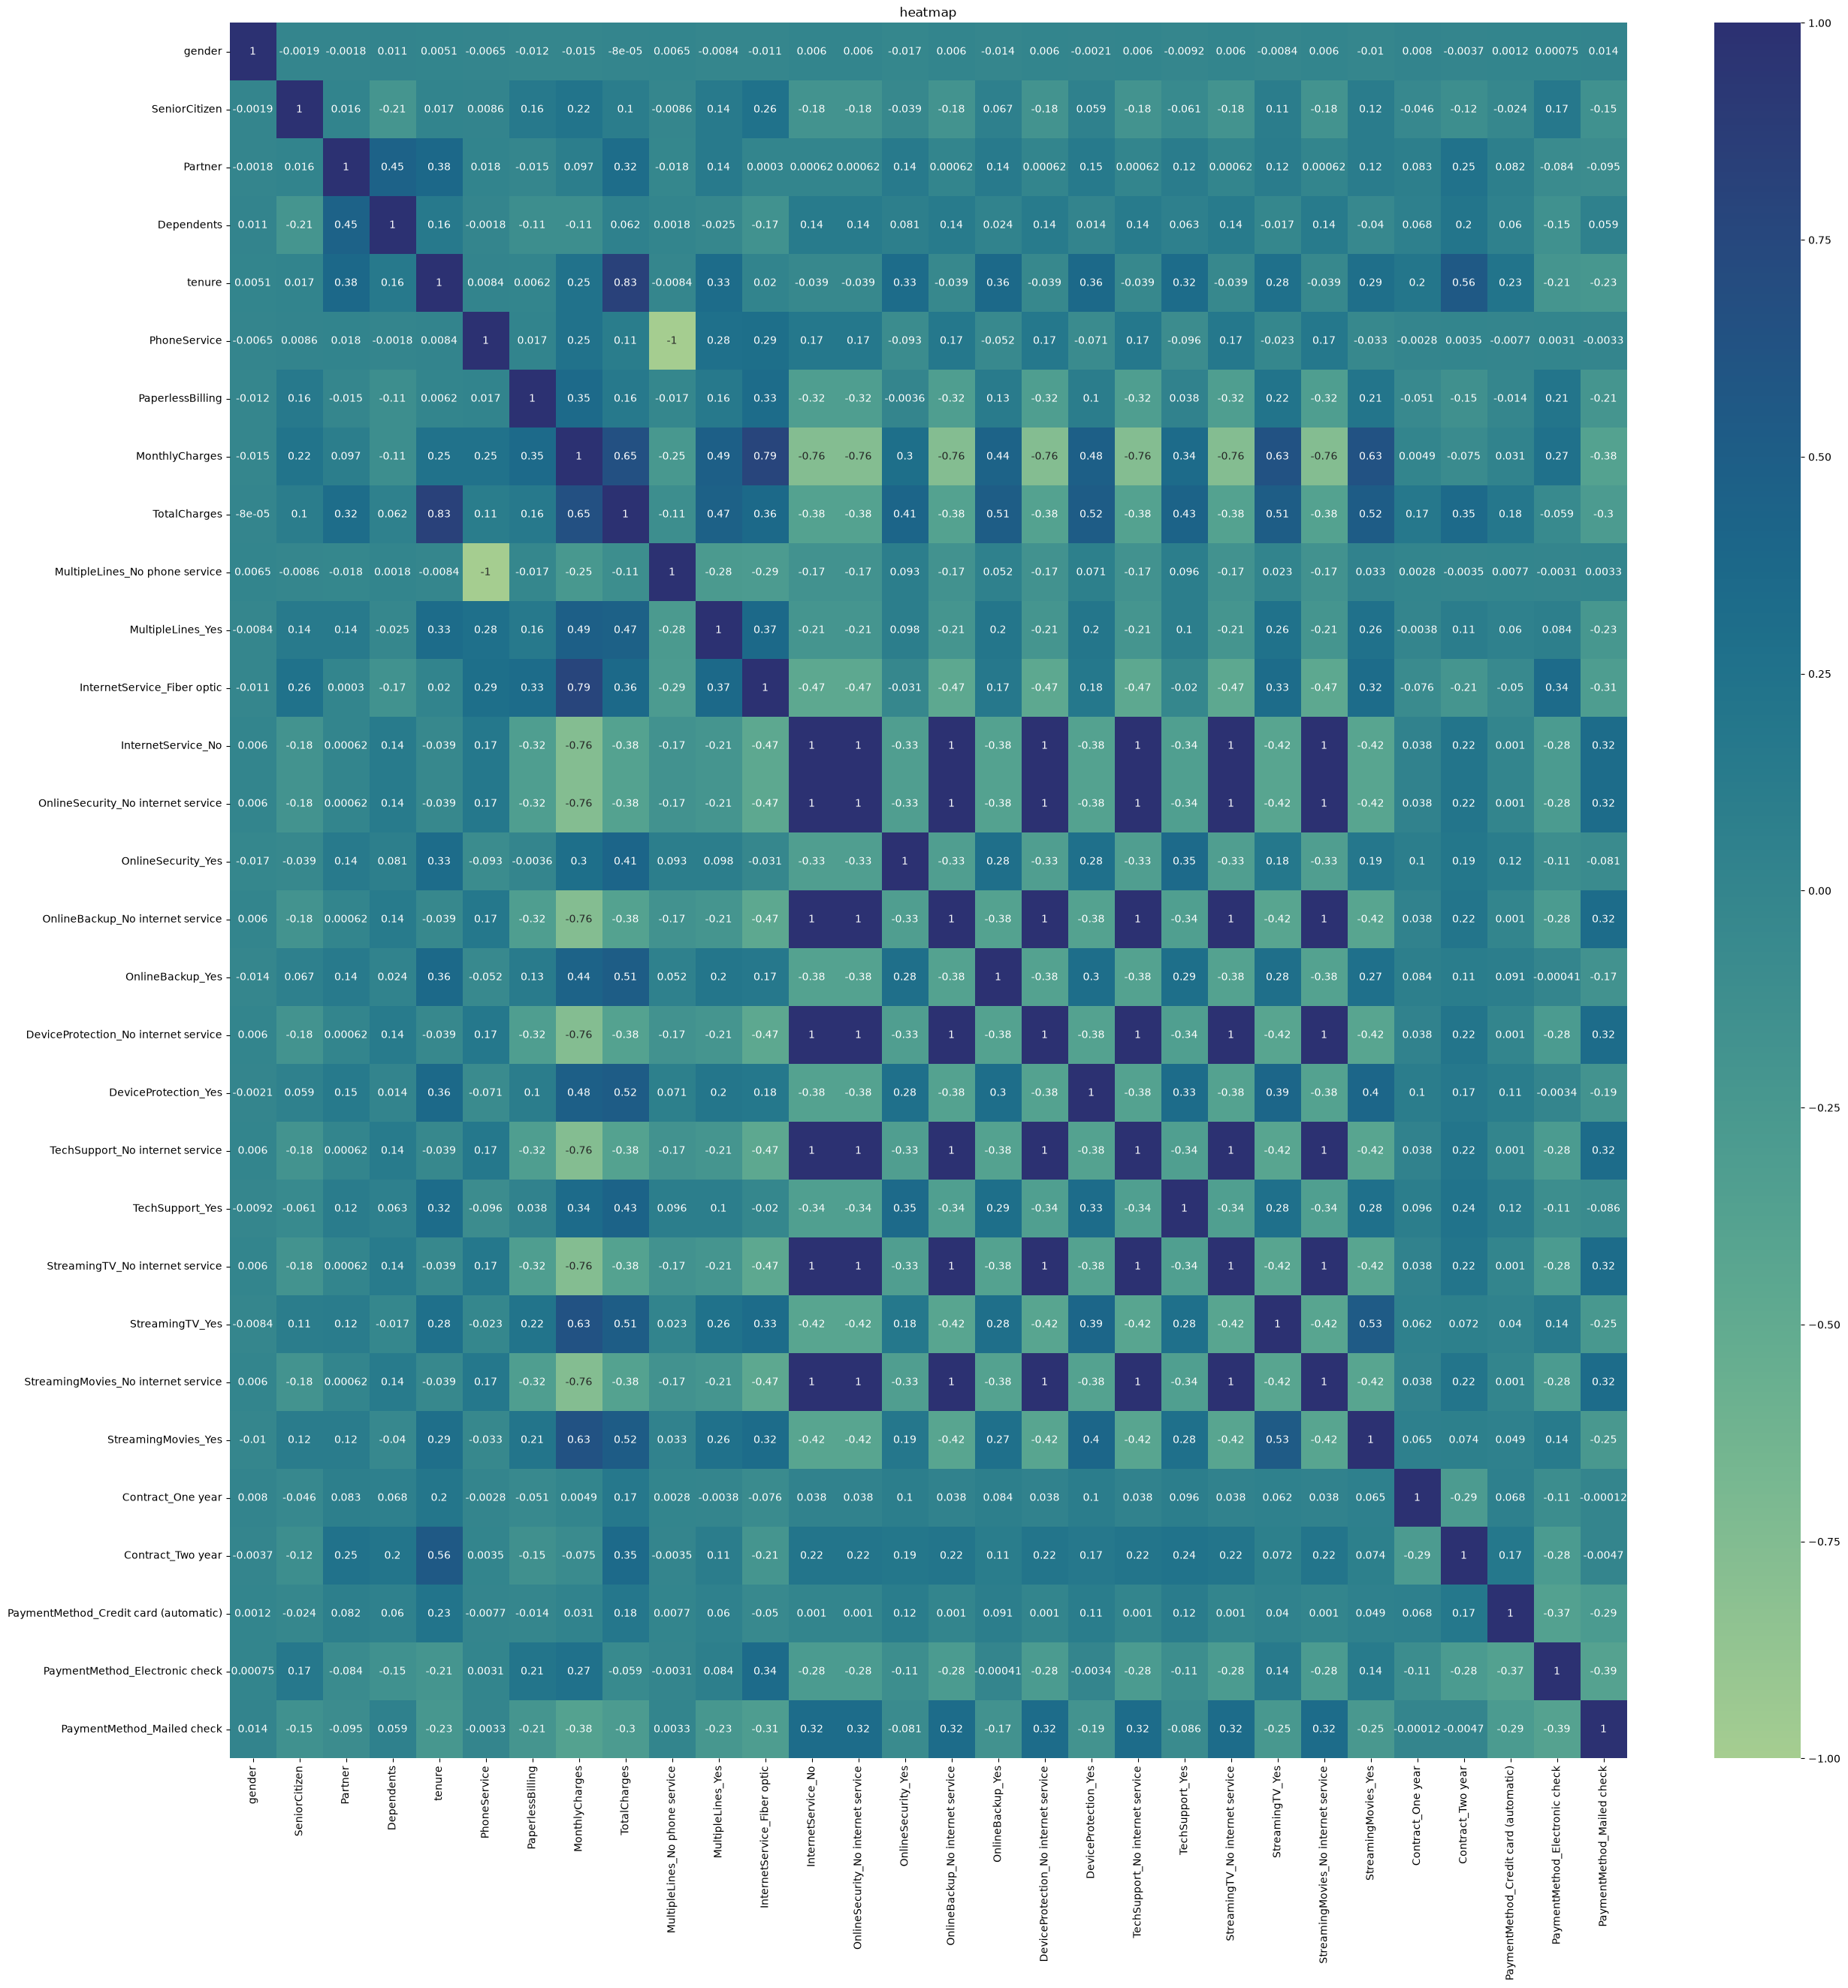

In [105]:
plt.figure(figsize=(30,30))
sns.heatmap(X[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']].corr(), annot=True, cmap="crest")
plt.title("heatmap")
plt.show()

In [ ]:
#there were no outliers initially in the dataset so we dont need to isolate the data without the outliers 
#regression models tend to be sesitive towards outliers

In [103]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [107]:
#target data columns 
y=df1['Churn_binary']
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_binary, dtype: int64

In [125]:
#splitting the training data into training an dtestin set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [126]:
#logical regression model 
log_clf=LogisticRegression(random_state=42,max_iter=300).fit(X_train,y_train)

c:\Users\Dell\env1\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [127]:
#using model to predict on test set
y_predict=log_clf.predict(X_test)
print(y_predict)


[0 0 0 ... 0 0 0]


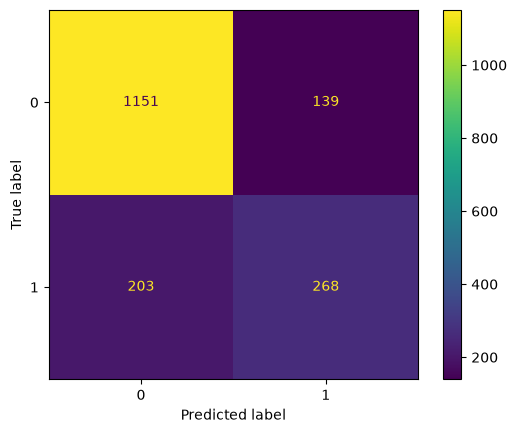

In [128]:
#computing confusion matrix
log_cm=confusion_matrix(y_test,y_predict,labels=log_clf.classes_)

#display for confusion matrix
log_disp=ConfusionMatrixDisplay(confusion_matrix=log_cm,display_labels=log_clf.classes_)

#plotting the confusion matrix
log_disp.plot(values_format='')
plt.show()

In [129]:
# Create classification report for logistic regression model
target_names = ['Predicted would not Churn', 'Predicted would Churn']
print(classification_report(y_test, y_predict, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not Churn       0.85      0.89      0.87      1290
    Predicted would Churn       0.66      0.57      0.61       471

                 accuracy                           0.81      1761
                macro avg       0.75      0.73      0.74      1761
             weighted avg       0.80      0.81      0.80      1761

